In [5]:
import pandas as pd
df = pd.read_csv("/Users/sujithrathod/krish naik /linear regression/height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

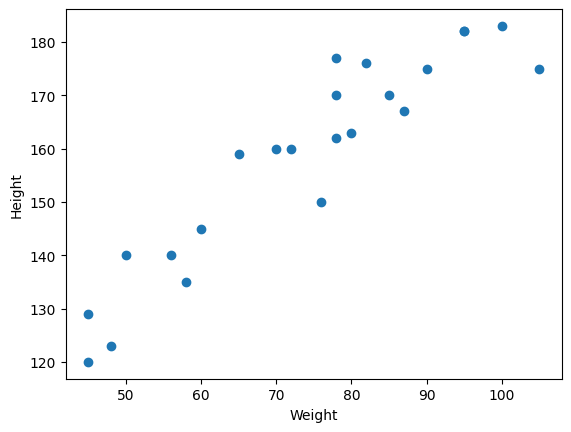

In [8]:

# scatter plot
import matplotlib.pyplot as plt
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [9]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


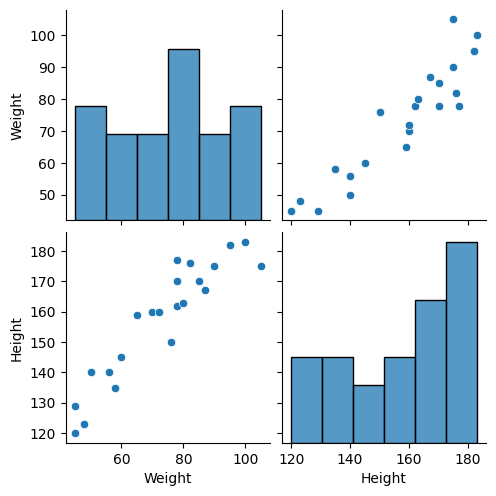

In [10]:
# seaborn 
import seaborn as sns
sns.pairplot(df)

In [20]:
# independant and dependent features
x = df[['Weight']]     #should be dataframe not in series
y = df['Height']       #this variable can be in series or 1d array


In [23]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [24]:
x_train.shape

(18, 1)

In [ ]:
# standardization
# convert the different unit data into mean = 0 , standard_deviation = 1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)   #fit_transform for calculate mean and standard deviation

In [26]:
x_train

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

In [27]:
x_test = scaler.transform(x_test)

In [28]:
x_test

array([[ 0.21043706],
       [ 0.21043706],
       [-1.6552288 ],
       [ 1.17153765],
       [-0.52452222]])

In [31]:
# apply linear Regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)

In [32]:
regression.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [33]:
regression.coef_

array([17.03440872])

In [34]:
regression.intercept_

np.float64(157.5)

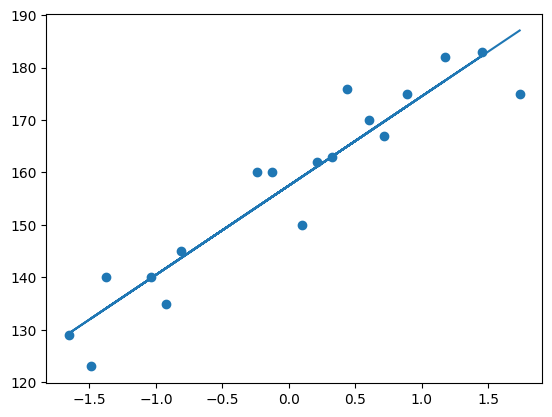

In [36]:
# plot training data plot best fit line
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train))

In [42]:
# prediction for test data
y_pred = regression.predict(x_test)
y_pred

array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
       148.56507414])

In [41]:
# prediction of test data
y_pred = 157.5 + 17.03440872 * (x_test[0])
y_pred

array([161.08467086])

In [44]:
# performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

In [45]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print("mse", mse)
print("mae" , mae)
print("rmse", rmse)

mse 109.77592599051664
mae 9.822657814519232
rmse 10.477400726827081


In [46]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
score

0.776986986042344

In [49]:
# OLS linear regression
import statsmodels.api as sm

In [52]:
model = sm.OLS(y_train,x_train).fit()

In [55]:
prediction = model.predict(x_test)
prediction

array([  3.58467086,   3.58467086, -28.1958439 ,  19.95645118,
        -8.93492586])

In [54]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.047
Method:                 Least Squares   F-statistic:                             0.1986
Date:                Mon, 10 Nov 2025   Prob (F-statistic):                       0.661
Time:                        00:21:59   Log-Likelihood:                         -116.62
No. Observations:                  18   AIC:                                      235.2
Df Residuals:                      17   BIC:                                      236.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------